# Dataset

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Data Preprocessing

In [6]:
df=pd.read_csv('clean_nutrition_dataset.csv')
df.head(100)

,fdc_id,food_name,carbs,calories,fiber,iron,magnesium,protein,sodium,fat,category
0,1105904,WESSON Vegetable Oil 1 GAL,0.00,867.0,0.0,0.00,0.0,0.00,0.0,93.33,Others
1,1105905,SWANSON BROTH BEEF,0.42,4.0,0.0,0.00,0.0,0.83,346.0,0.00,Others
2,1105906,CAMPBELL'S SLOW KETTLE SOUP CLAM CHOWDER,6.12,82.0,0.4,0.24,0.0,2.45,363.0,5.31,Others
3,1105907,CAMPBELL'S SLOW KETTLE SOUP CHEESE BROCCOLI,5.31,82.0,0.4,0.16,0.0,1.22,322.0,6.12,Others
4,1105908,SWANSON BROTH CHICKEN,0.42,4.0,0.0,0.00,0.0,0.83,15.0,0.00,Others
...,...,...,...,...,...,...,...,...,...,...,...
95,1105999,Pork Loin Chop Porterhouse,0.00,80.0,0.0,0.00,0.0,17.86,304.0,8.93,Others
96,1106000,"Pork Loin Bone In Center Cut All Natural 1/8""""...",0.00,71.0,0.0,0.64,0.0,18.75,286.0,8.04,Others
97,1106001,Pork Loin Bone In Center Cut False Lean Remove...,0.00,71.0,0.0,0.32,0.0,19.64,45.0,8.04,Others
98,1106002,Pork Loin Bone In Chine Removed Chop with Jala...,1.79,71.0,0.0,0.64,0.0,16.96,812.0,8.04,Others


In [7]:
df.shape

(1913614, 11)

In [8]:
df.duplicated()

0          False
1          False
2          False
3          False
4          False
           ...  
1913609    False
1913610    False
1913611    False
1913612    False
1913613    False
Length: 1913614, dtype: bool

In [9]:
df = df.drop_duplicates()

In [10]:
df.describe()

,fdc_id,carbs,calories,fiber,iron,magnesium,protein,sodium,fat
count,1.913614e+06,1.913614e+06,1.913614e+06,1.913614e+06,1.913614e+06,1.913614e+06,1.913614e+06,1.913614e+06,1.913614e+06
mean,1.604080e+06,3.373947e+01,2.686516e+02,2.432781e+00,3.893856e+00,7.615408e+00,7.533334e+00,1.481318e+03,1.226813e+01
std,7.054536e+05,4.882217e+01,3.567511e+02,7.058021e+00,6.860759e+02,1.061159e+03,1.421699e+01,9.639413e+04,2.211529e+01
min,1.675120e+05,-7.050000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.090500e+06,6.560000e+00,8.100000e+01,0.000000e+00,0.000000e+00,0.000000e+00,5.000000e-02,3.300000e+01,0.000000e+00
50%,1.665186e+06,2.231000e+01,2.590000e+02,8.000000e-01,5.600000e-01,0.000000e+00,4.580000e+00,2.540000e+02,5.130000e+00
75%,2.176232e+06,5.957000e+01,4.000000e+02,3.300000e+00,1.980000e+00,0.000000e+00,1.053000e+01,5.650000e+02,1.905000e+01
max,2.751503e+06,1.270000e+04,1.515150e+05,2.468900e+03,7.692308e+05,5.857140e+05,4.444440e+03,4.000000e+07,3.666670e+03


In [11]:
df.describe(include='object')

,food_name,category
count,1913614,1913614
unique,483487,26
top,ICE CREAM,Others
freq,2451,1892304


In [12]:
df.isnull().sum()

fdc_id       0
food_name    0
carbs        0
calories     0
fiber        0
iron         0
magnesium    0
protein      0
sodium       0
fat          0
category     0
dtype: int64

# EDA

Visualize patterns using seaborn, matplotlib and please explain each graph

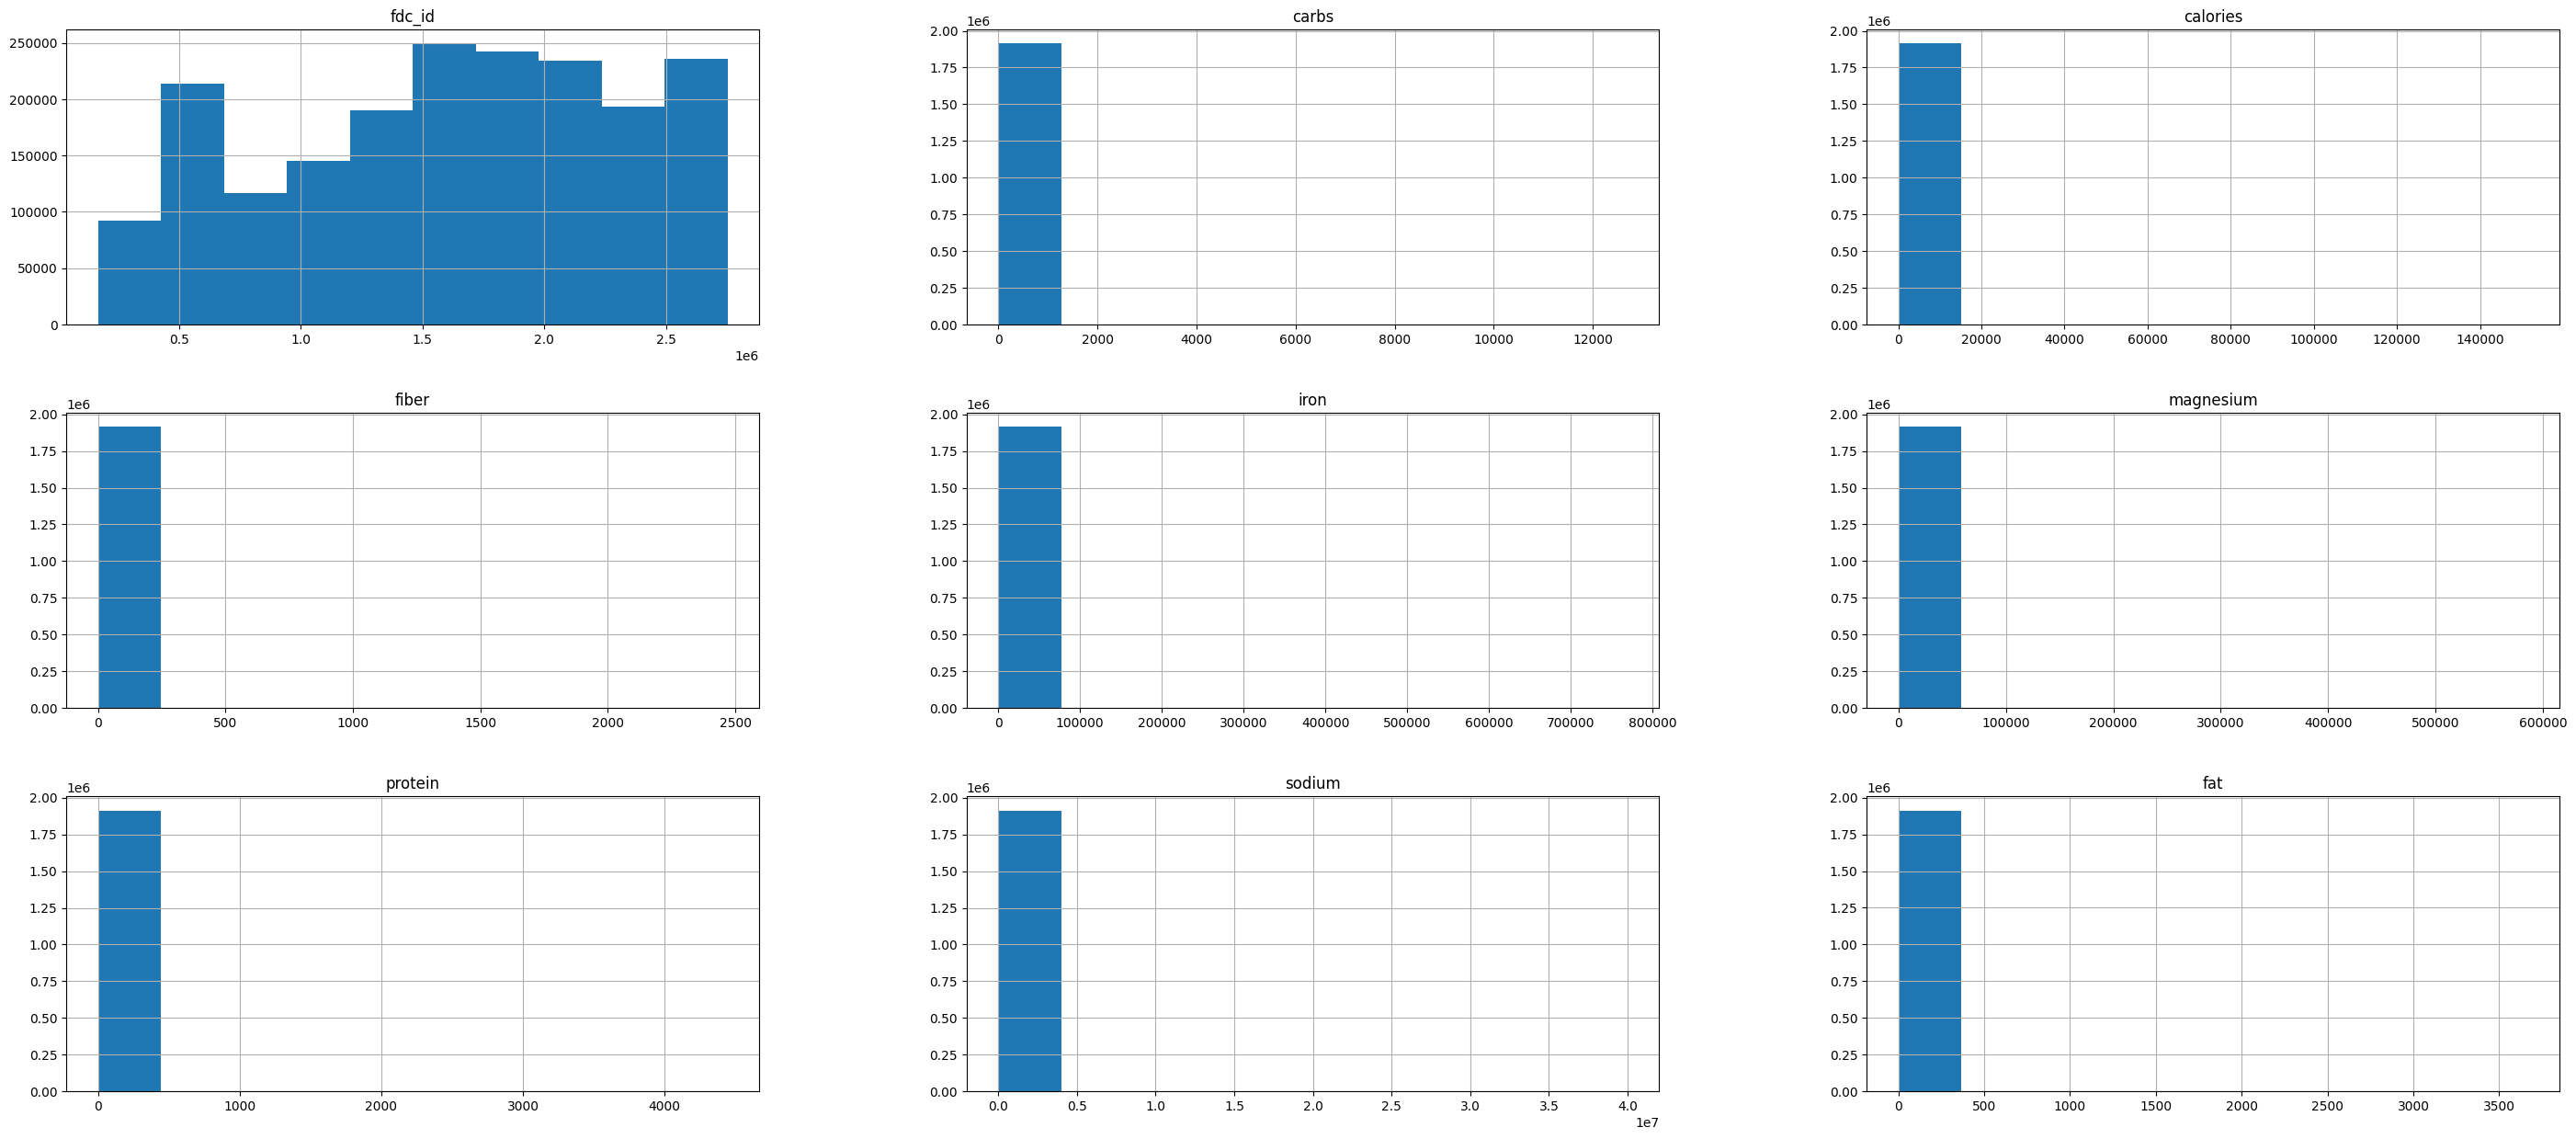

In [13]:
df.hist(figsize=(35,15))
plt.show()

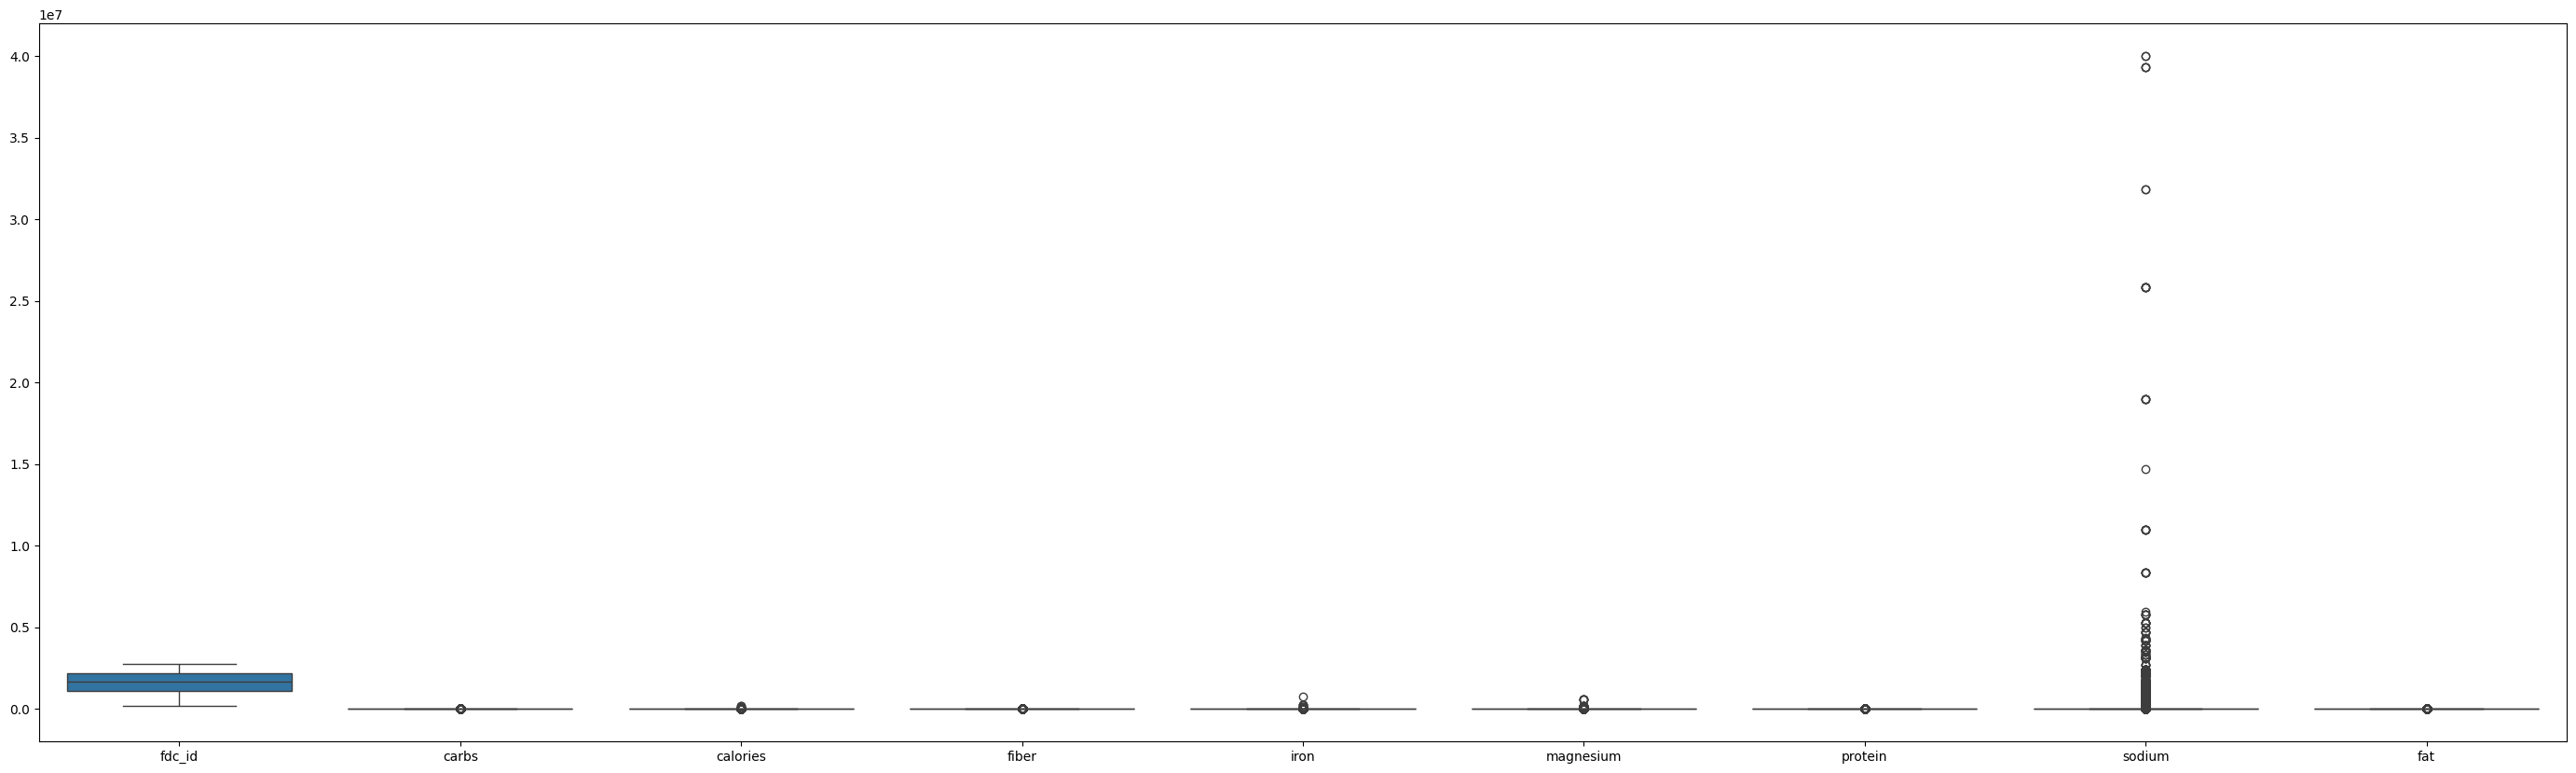

In [14]:
plt.figure(figsize=(35,10))
sns.boxplot(data=df)
plt.show()

In [15]:
for col in df.select_dtypes(include='object').columns:
    print(df[col].value_counts())
    print("-"*30)

food_name
ICE CREAM                                        2451
2% REDUCED FAT MILK                              1744
EXTRA VIRGIN OLIVE OIL                           1520
POTATO CHIPS                                     1517
CUT GREEN BEANS                                  1399
                                                 ... 
FRESH-PACK PICKLE SPEARS, SPICY MAPLE BOURBON       1
MARKET PANTRY, BANANA PEPPER RINGS, MILD            1
SALSA, CASERA                                       1
QUEEN OLIVES, JALAPENO STUFFED                      1
POULTRY SEASONING SALT                              1
Name: count, Length: 483487, dtype: int64
------------------------------
category
Others                                 1892304
Vegetables and Vegetable Products         4210
Fruits and Fruit Juices                   2381
Legumes and Legume Products               1913
Dairy and Egg Products                    1864
Cereal Grains and Pasta                   1547
Beef Products                   

Text(0.5, 1.0, 'Correlation Heatmap')

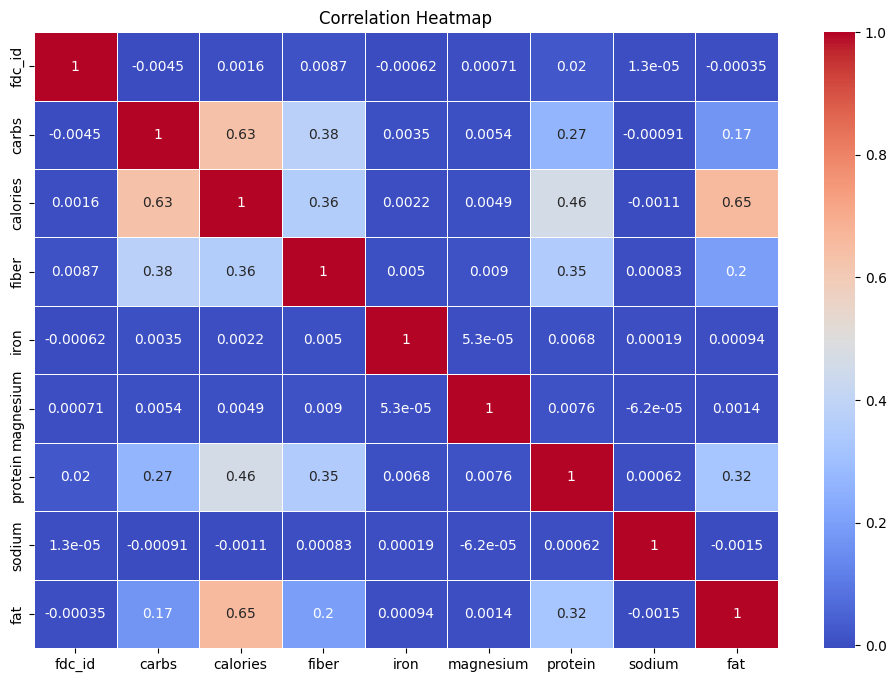

In [16]:
heatmap_data = df.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', linewidths=0.5,)
plt.title('Correlation Heatmap')

<Figure size 2000x1000 with 0 Axes>

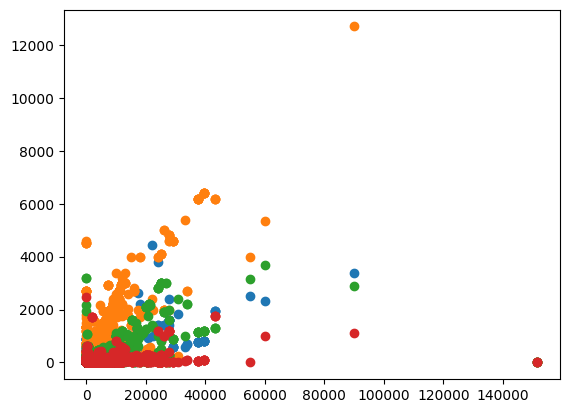

<Figure size 2000x1000 with 0 Axes>

In [17]:
figure1=plt.scatter(x='calories',y='protein',data=df)
figure2=plt.scatter(x='calories',y='carbs',data=df)
figure3=plt.scatter(x='calories',y='fat',data=df)
figure4=plt.scatter(x='calories',y='fiber',data=df)
plt.figure(figsize=(20,10))


## Handling outlayers

In [18]:


def remove_outliers_iqr(df, columns):
    cleaned_df = df.copy()
    
    for col in columns:
        Q1 = cleaned_df[col].quantile(0.25)
        Q3 = cleaned_df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        cleaned_df = cleaned_df[(cleaned_df[col] >= lower) & (cleaned_df[col] <= upper)]
        
    return cleaned_df

num_cols = ['carbs', 'calories', 'fiber', 'iron', 'magnesium', 'protein', 'sodium', 'fat']

df_clean = remove_outliers_iqr(df, num_cols)
print("Before:", df.shape)
print("After :", df_clean.shape)

Before: (1913614, 11)
After : (1416969, 11)


In [19]:
df_clean.head()

,fdc_id,food_name,carbs,calories,fiber,iron,magnesium,protein,sodium,fat,category
1,1105905,SWANSON BROTH BEEF,0.42,4.0,0.0,0.00,0.0,0.83,346.0,0.00,Others
2,1105906,CAMPBELL'S SLOW KETTLE SOUP CLAM CHOWDER,6.12,82.0,0.4,0.24,0.0,2.45,363.0,5.31,Others
3,1105907,CAMPBELL'S SLOW KETTLE SOUP CHEESE BROCCOLI,5.31,82.0,0.4,0.16,0.0,1.22,322.0,6.12,Others
4,1105908,SWANSON BROTH CHICKEN,0.42,4.0,0.0,0.00,0.0,0.83,15.0,0.00,Others
5,1105909,CAMPBELL'S SOUP BEAN AND HAM,10.61,61.0,2.4,0.82,0.0,3.67,306.0,0.61,Others


<Figure size 2000x1000 with 0 Axes>

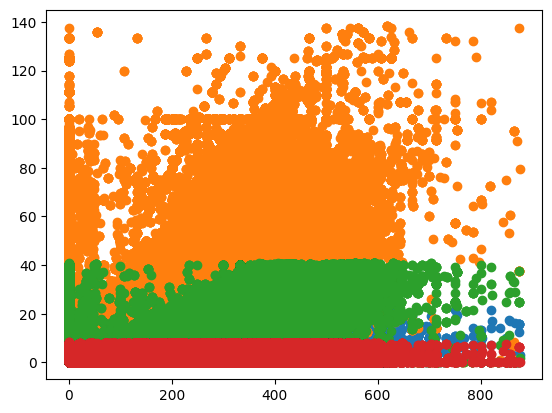

<Figure size 2000x1000 with 0 Axes>

In [20]:
figure1=plt.scatter(x='calories',y='protein',data=df_clean)
figure2=plt.scatter(x='calories',y='carbs',data=df_clean)
figure3=plt.scatter(x='calories',y='fat',data=df_clean)
figure4=plt.scatter(x='calories',y='fiber',data=df_clean)
plt.figure(figsize=(20,10))


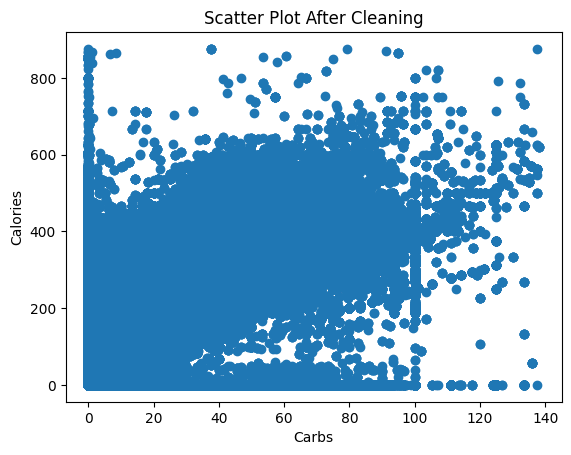

In [21]:
import matplotlib.pyplot as plt

plt.scatter(df_clean['carbs'], df_clean['calories'])
plt.xlabel("Carbs")
plt.ylabel("Calories")
plt.title("Scatter Plot After Cleaning")
plt.show()


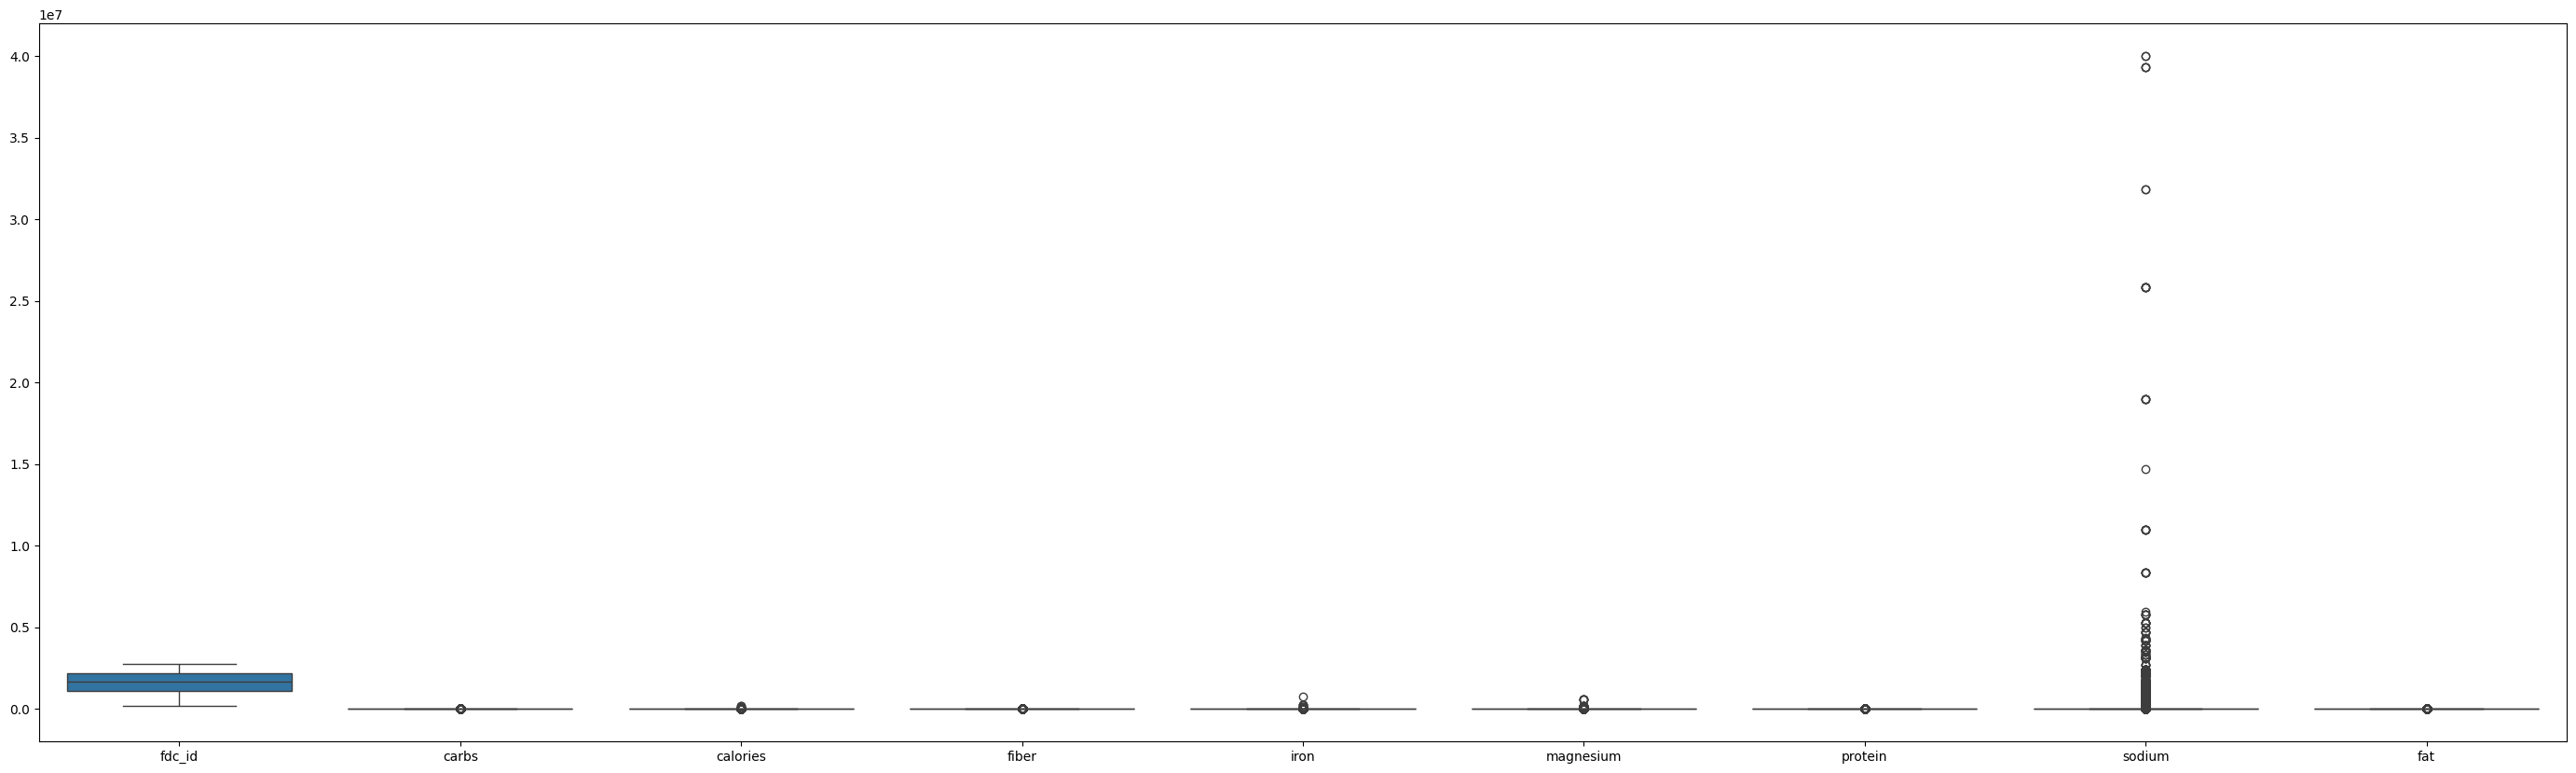

In [22]:
plt.figure(figsize=(35,10))
sns.boxplot(data=df)
plt.show()

## Scaling

In [23]:
from sklearn.preprocessing import StandardScaler

features = ['carbs', 'fat', 'protein', 'fiber', 'iron', 'magnesium', 'sodium']
target = ['calories']

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X = scaler_X.fit_transform(df_clean[features])
y = scaler_y.fit_transform(df_clean[target])

## Feature ENG

In [24]:


# Guard against zeros before ratios
df_clean['macro_sum'] = (df_clean['carbs'] + df_clean['protein'] + df_clean['fat']).replace(0, np.nan)
df_clean['calories'] = df_clean['calories'].replace(0, np.nan)

# Engineered features
df_clean['calorie_density'] = df_clean['calories'] / 100
df_clean['carb_ratio'] = df_clean['carbs'] / df_clean['macro_sum']
df_clean['protein_ratio'] = df_clean['protein'] / df_clean['macro_sum']
df_clean['fat_ratio'] = df_clean['fat'] / df_clean['macro_sum']
df_clean['nutrient_density'] = df_clean['macro_sum'] / df_clean['calories']

# Final feature list used downstream
final_features = [
    'carbs', 'fat', 'protein', 'fiber', 'iron', 'magnesium', 'sodium',
    'calorie_density',
    'carb_ratio', 'protein_ratio', 'fat_ratio',
    'nutrient_density'
 ]

# Clean up infinities and drop rows missing engineered features
df_clean = df_clean.replace([np.inf, -np.inf], np.nan)
df_clean = df_clean.dropna(subset=final_features + ['calories'])

In [25]:
final_features = [
    'carbs', 'fat', 'protein', 'fiber', 'iron', 'magnesium', 'sodium',
    'calorie_density',
    'carb_ratio', 'protein_ratio', 'fat_ratio',
    'nutrient_density'
]

In [26]:
X = scaler_X.fit_transform(df_clean[final_features])
y = scaler_y.fit_transform(df_clean[['calories']])

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[final_features])

# Modeling

### ML_Model_1

In [28]:
from sklearn.cluster import KMeans

k = 6
kmeans = KMeans(n_clusters=k, random_state=42)
df_clean['cluster'] = kmeans.fit_predict(X_scaled)

In [29]:
import numpy as np

embeddings = X_scaled  # already scaled
df_clean['embedding'] = list(embeddings)

In [30]:
import sys
!{sys.executable} -m pip install rapidfuzz


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\moham\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [31]:
from sklearn.metrics.pairwise import cosine_similarity
from rapidfuzz import process, fuzz
import numpy as np

def find_closest_food(query):
    choices = df_clean['food_name'].values
    match, score, idx = process.extractOne(query, choices, scorer=fuzz.WRatio)
    return match

def recommend(query, top_n=5):

    # 1. Find closest matching food name
    food_name = find_closest_food(query)

    # 2. Get index
    idx = df_clean.index[df_clean['food_name'] == food_name][0]

    # 3. Vector
    food_vec = df_clean.loc[idx, 'embedding'].reshape(1, -1)

    # 4. Similarity
    sims = cosine_similarity(food_vec, np.vstack(df_clean['embedding'])).flatten()

    # 5. Sort
    df_clean['similarity'] = sims
    results = (
        df_clean.sort_values(by='similarity', ascending=False)
        [['food_name', 'category', 'similarity', 'cluster']]
        .head(top_n+1)[1:]
    )

    print(f"Input: {query}\nMatched: {food_name}")
    return results

In [32]:
recommend("oats")

Input: oats
Matched: OEP Mini Flour Tort Boats 12Ct


,food_name,category,similarity,cluster
553487,OEP Flr Trtilla Taco Boat 8Ct,Others,1.0,4
1073697,Old El Paso Soft Flour Tortilla Taco Bowls,Others,1.0,4
788436,OEP Mini Flour Tort Boats 12Ct,Others,1.0,4
1073858,Old El Paso Soft Mini Flour Tortilla Bowl Valu...,Others,1.0,4
378495,Old El Paso Mini Flour Tortilla Taco Boats 12 ...,Others,1.0,4


### 2nd Model (prediction for callories)

the same featured features

In [33]:
final_features = [
    'carbs', 'fat', 'protein', 'fiber', 'iron', 'magnesium', 'sodium',
    'calorie_density',
    'carb_ratio', 'protein_ratio', 'fat_ratio',
    'nutrient_density'
]

X = df_clean[final_features]
y = df_clean['calories']

normalized


In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1,1))

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

XGBoost Model

In [35]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror'
)

xgb.fit(X_train, y_train.ravel())

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

Evaluate XGBoost

In [36]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
pred_scaled = xgb.predict(X_test).reshape(-1,1)
pred = scaler_y.inverse_transform(pred_scaled)
y_real = scaler_y.inverse_transform(y_test)

rmse = np.sqrt(mean_squared_error(y_real, pred))
mae = mean_absolute_error(y_real, pred)

print("XGBoost RMSE:", rmse)
print("XGBoost MAE :", mae)

XGBoost RMSE: 1.6132000755060818
XGBoost MAE : 0.9823173911516069


predction

In [37]:
def predict_calories_xgb(sample_dict):

    # Convert dictionary → DataFrame
    df_inp = pd.DataFrame([sample_dict])[final_features]

    # Scale input
    scaled = scaler_X.transform(df_inp)

    # Predict (scaled calories)
    pred_scaled = xgb.predict(scaled).reshape(-1,1)

    # Convert back to real calories
    predicted = scaler_y.inverse_transform(pred_scaled)

    return predicted[0][0]  # return number only


# Example sample input
sample = {
    'carbs': 30,
    'fat': 5,
    'protein': 12,
    'fiber': 4,
    'iron': 2,
    'magnesium': 20,
    'sodium': 180,
    'calorie_density': 1.3,
    'carb_ratio': 0.55,
    'protein_ratio': 0.25,
    'fat_ratio': 0.20,
    'nutrient_density': 0.03
}

cal = predict_calories_xgb(sample)
print("Predicted Calories:", cal)

Predicted Calories: 146.62125


In [38]:
recommend("oats")

Input: oats
Matched: OEP Mini Flour Tort Boats 12Ct


,food_name,category,similarity,cluster
553487,OEP Flr Trtilla Taco Boat 8Ct,Others,1.0,4
1073697,Old El Paso Soft Flour Tortilla Taco Bowls,Others,1.0,4
788436,OEP Mini Flour Tort Boats 12Ct,Others,1.0,4
1073858,Old El Paso Soft Mini Flour Tortilla Bowl Valu...,Others,1.0,4
378495,Old El Paso Mini Flour Tortilla Taco Boats 12 ...,Others,1.0,4
